**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

# Multi-Layer Fully Connected Network / 多层全连接网络

In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.
**在本练习中，你将实现一个具有任意数量隐藏层的全连接网络。**

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.
**阅读文件`cs231n/classifiers/fc_net.py`中的`FullyConnectedNet`类。**

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.
**实现网络初始化、前向传播和反向传播。在整个作业中，你将在`cs231n/layers.py`中实现各种层。你可以复用之前实现的`affine_forward`、`affine_backward`、`relu_forward`、`relu_backward`和`softmax_loss`。暂时不用担心实现dropout或批量/层归一化，你稍后会添加这些功能。**

In [2]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

d:\Desktop\Deep_Learning\dl_assignments\assignment1\cs231n\data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check / 初始损失和梯度检查

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.
**作为健全性检查，运行以下代码检查初始损失，并对网络进行带和不带正则化的梯度检查。这是判断初始损失是否合理的好方法。**

For gradient checking, you should expect to see errors around 1e-7 or less.
**对于梯度检查，你应该预期看到约1e-7或更小的误差。**

In [4]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.302097302967627
W1 relative error: 0.001086059057830691
W2 relative error: 9.942088029095716e-07
W3 relative error: 3.143960640735375e-07
b1 relative error: 3.399774358305235e-05
b2 relative error: 1.331602938621169e-09
b3 relative error: 1.7848917333018093e-10
Running check with reg =  3.14
Initial loss:  7.052442290138279
W1 relative error: 2.0222993974521795e-08
W2 relative error: 1.6409334672495597e-08
W3 relative error: 2.02499323473282e-07
b1 relative error: 2.8355894339978635e-08
b2 relative error: 8.71465967077484e-09
b3 relative error: 1.1634869077899808e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.
**作为另一个健全性检查，确保你的网络能够在50张图像的小数据集上过拟合。首先，我们将尝试一个三层网络，每个隐藏层有100个单元。在下面的cell中，调整**学习率**和**权重初始化尺度**以过拟合并在20个轮次内达到100%的训练准确率。**

(Iteration 1 / 40) loss: 2.299724
(Epoch 0 / 20) train acc: 0.080000; val_acc: 0.131000
(Epoch 1 / 20) train acc: 0.100000; val_acc: 0.132000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.130000
(Epoch 3 / 20) train acc: 0.100000; val_acc: 0.130000
(Epoch 4 / 20) train acc: 0.100000; val_acc: 0.130000
(Epoch 5 / 20) train acc: 0.120000; val_acc: 0.132000
(Iteration 11 / 40) loss: 2.264167
(Epoch 6 / 20) train acc: 0.120000; val_acc: 0.133000
(Epoch 7 / 20) train acc: 0.120000; val_acc: 0.130000
(Epoch 8 / 20) train acc: 0.120000; val_acc: 0.134000
(Epoch 9 / 20) train acc: 0.120000; val_acc: 0.132000
(Epoch 10 / 20) train acc: 0.140000; val_acc: 0.132000
(Iteration 21 / 40) loss: 2.246832
(Epoch 11 / 20) train acc: 0.140000; val_acc: 0.134000
(Epoch 12 / 20) train acc: 0.140000; val_acc: 0.138000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.135000
(Epoch 14 / 20) train acc: 0.200000; val_acc: 0.136000
(Epoch 15 / 20) train acc: 0.220000; val_acc: 0.135000
(Iteration 31 / 40) loss: 

c:\Users\Dinking\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dinking\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dinking\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dinking\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dinking\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from fon

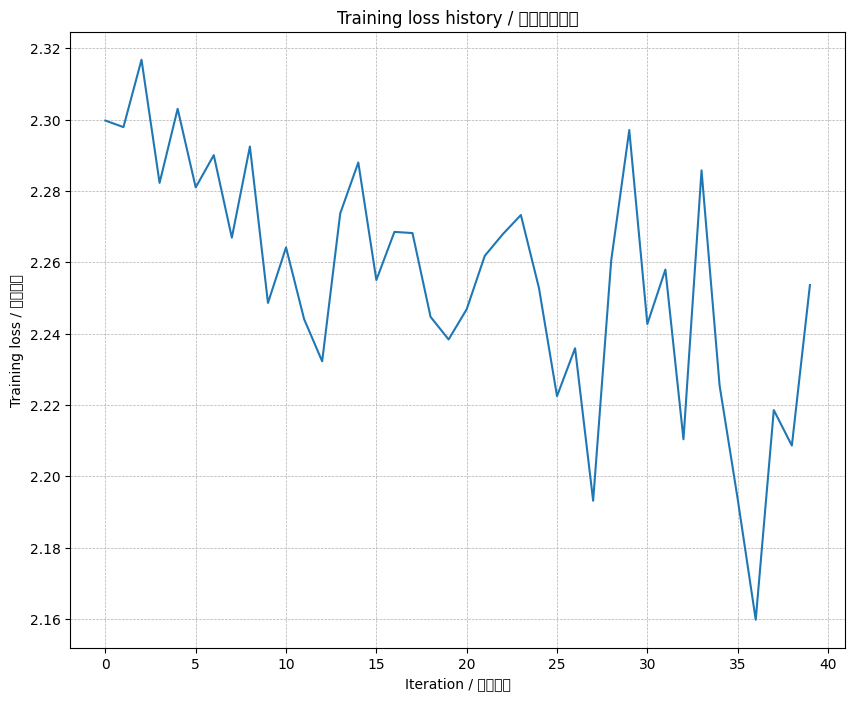

In [5]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.
# TODO: 使用三层网络在50个训练样本上过拟合，
# 仅需调整学习率和初始化尺度。

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 1e-2   # Experiment with this! / 尝试调整这个！
learning_rate = 1e-4  # Experiment with this! / 尝试调整这个！


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history / 训练损失历史")
plt.xlabel("Iteration / 迭代次数")
plt.ylabel("Training loss / 训练损失")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.
**现在，尝试使用一个五层网络，每层100个单元，在50个训练样本上过拟合。同样，你需要调整学习率和权重初始化尺度，但你应该能够在20个轮次内达到100%的训练准确率。**

(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 11 / 40) loss: 2.301962
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.301859
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 31 / 40) loss: 

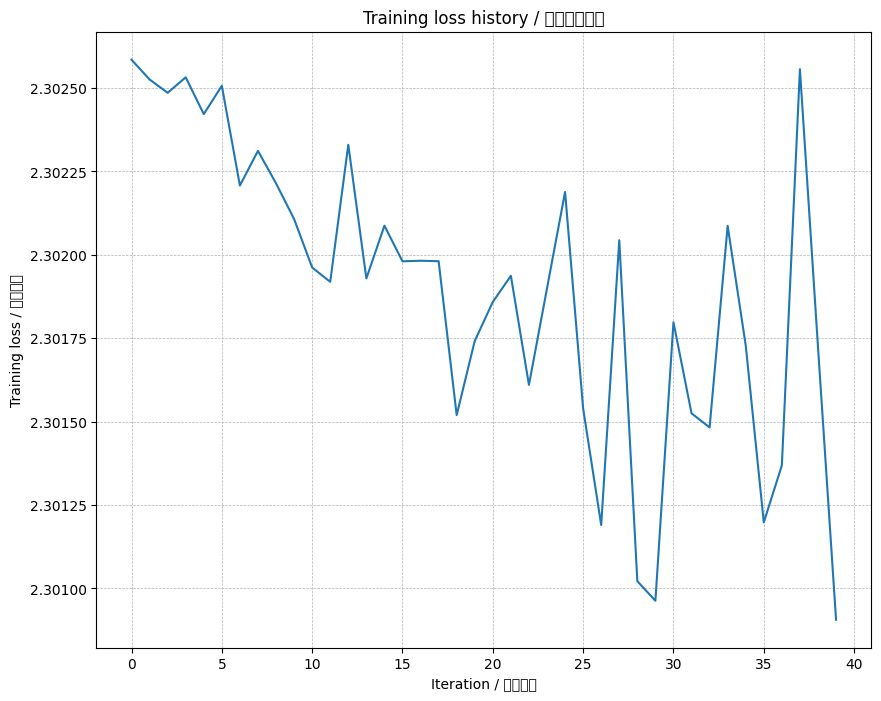

In [6]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.
# TODO: 使用五层网络在50个训练样本上过拟合，
# 仅需调整学习率和初始化尺度。

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 2e-3  # Experiment with this! / 尝试调整这个！
weight_scale = 1e-5   # Experiment with this! / 尝试调整这个！


model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history / 训练损失历史')
plt.xlabel('Iteration / 迭代次数')
plt.ylabel('Training loss / 训练损失')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## Inline Question 1: / ## 内联问题 1：
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?
**你注意到训练三层网络和训练五层网络的难度差异了吗？特别是，根据你的经验，哪个网络对初始化尺度更敏感？你认为为什么会这样？**

## Answer: / ## 答案：
[FILL THIS IN] / [填写此处]

# Update rules / 更新规则

So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.
**到目前为止，我们使用的是普通随机梯度下降(SGD)作为更新规则。更复杂的更新规则可以使训练深度网络更容易。我们将实现几个最常用的更新规则，并与普通SGD进行比较。**

## SGD+Momentum / SGD+动量

Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.
**带动量的随机梯度下降是一个广泛使用的更新规则，它倾向于使深度网络比普通随机梯度下降更快收敛。更多信息请参见http://cs231n.github.io/neural-networks-3/#sgd的Momentum Update部分。**

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.
**打开文件`cs231n/optim.py`并阅读文件顶部的文档以确保你理解API。在`sgd_momentum`函数中实现SGD+动量更新规则，并运行以下代码检查你的实现。你应该看到小于e-8的误差。**

In [7]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.
**完成后，运行以下代码使用SGD和SGD+动量训练一个六层网络。你应该看到SGD+动量更新规则收敛更快。**

Running with  sgd
(Iteration 1 / 200) loss: 2.406121
(Epoch 0 / 5) train acc: 0.118000; val_acc: 0.104000
(Iteration 11 / 200) loss: 2.253021
(Iteration 21 / 200) loss: 2.198018
(Iteration 31 / 200) loss: 2.165732
(Epoch 1 / 5) train acc: 0.217000; val_acc: 0.205000
(Iteration 41 / 200) loss: 2.139277
(Iteration 51 / 200) loss: 2.094166
(Iteration 61 / 200) loss: 2.044255
(Iteration 71 / 200) loss: 2.084846
(Epoch 2 / 5) train acc: 0.309000; val_acc: 0.267000
(Iteration 81 / 200) loss: 1.928602
(Iteration 91 / 200) loss: 2.055612
(Iteration 101 / 200) loss: 2.082991
(Iteration 111 / 200) loss: 1.948278
(Epoch 3 / 5) train acc: 0.334000; val_acc: 0.286000
(Iteration 121 / 200) loss: 1.850099
(Iteration 131 / 200) loss: 1.891291
(Iteration 141 / 200) loss: 1.944460
(Iteration 151 / 200) loss: 1.890825
(Epoch 4 / 5) train acc: 0.336000; val_acc: 0.300000
(Iteration 161 / 200) loss: 1.815345
(Iteration 171 / 200) loss: 1.893190
(Iteration 181 / 200) loss: 1.764011
(Iteration 191 / 200) los

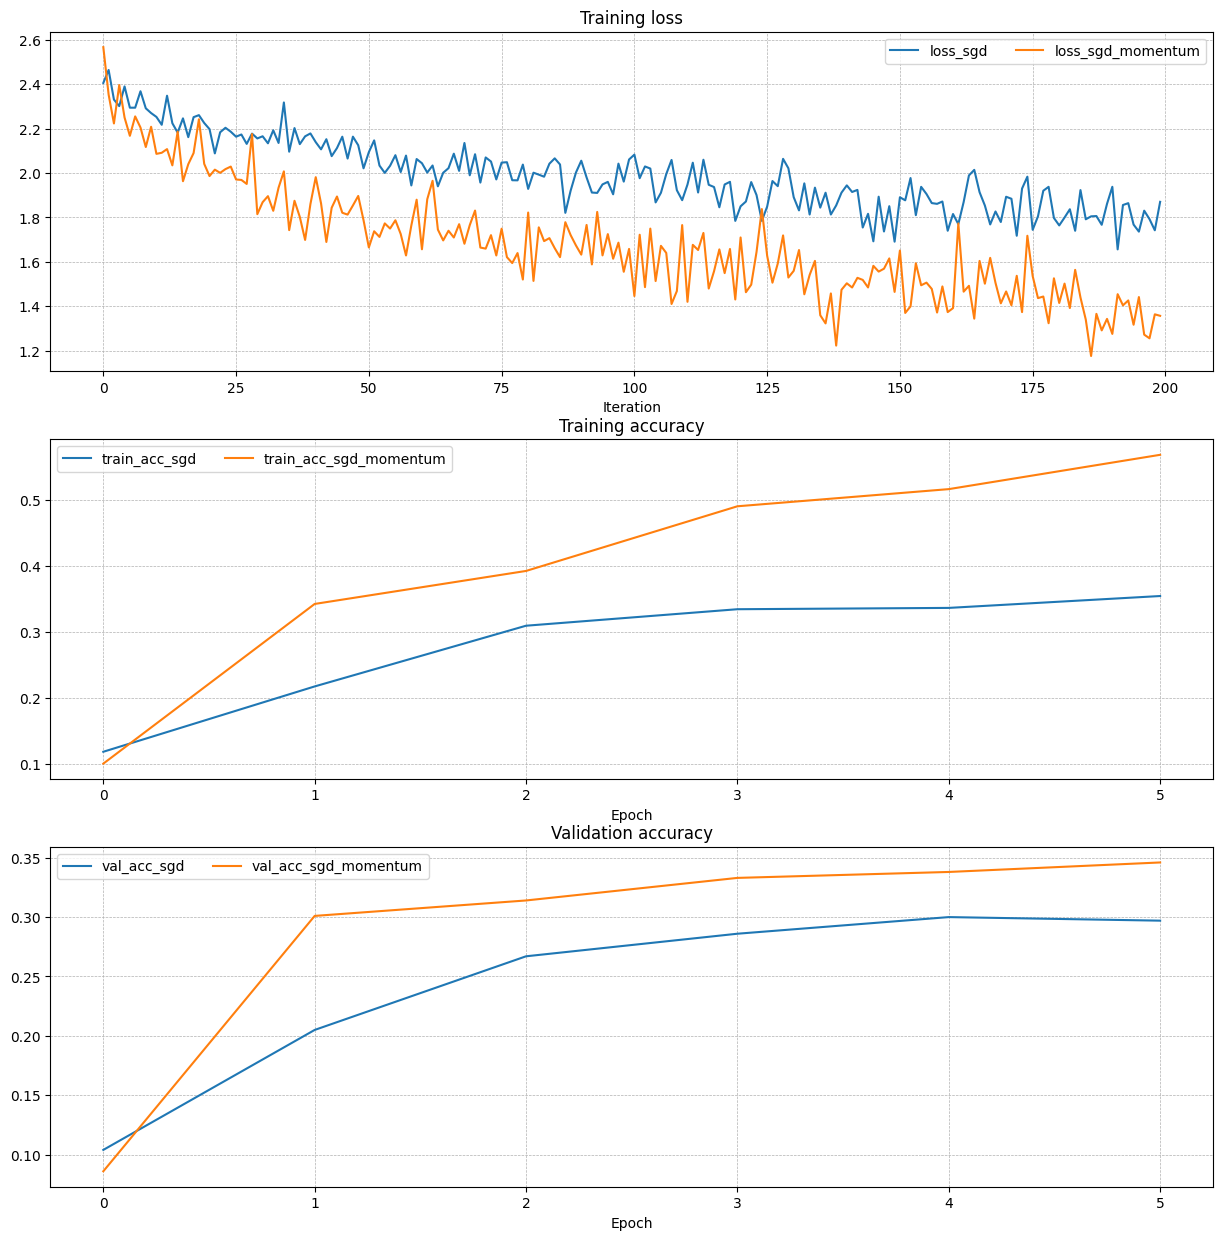

In [8]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam / RMSProp和Adam

RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.
**RMSProp [1] 和 Adam [2] 是通过使用梯度二阶矩的运行平均值来设置每个参数学习率的更新规则。**

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.
**在文件`cs231n/optim.py`中，在`rmsprop`函数中实现RMSProp更新规则，在`adam`函数中实现Adam更新规则，并使用以下测试检查你的实现。**

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.
**注意：请实现完整的Adam更新规则（带偏置校正机制），不要实现课程笔记中提到的第一个简化版本。**

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [13]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [14]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:
**完成RMSProp和Adam实现的调试后，运行以下代码使用这些新更新规则训练一对深度网络：**

Running with  adam
(Iteration 1 / 200) loss: 3.127898
(Epoch 0 / 5) train acc: 0.101000; val_acc: 0.086000
(Iteration 11 / 200) loss: 2.112590
(Iteration 21 / 200) loss: 2.271643
(Iteration 31 / 200) loss: 1.849839
(Epoch 1 / 5) train acc: 0.388000; val_acc: 0.309000
(Iteration 41 / 200) loss: 1.722607
(Iteration 51 / 200) loss: 1.801888
(Iteration 61 / 200) loss: 1.951693
(Iteration 71 / 200) loss: 1.461924
(Epoch 2 / 5) train acc: 0.405000; val_acc: 0.334000
(Iteration 81 / 200) loss: 1.649270
(Iteration 91 / 200) loss: 1.507698
(Iteration 101 / 200) loss: 1.372364
(Iteration 111 / 200) loss: 1.570623
(Epoch 3 / 5) train acc: 0.481000; val_acc: 0.335000
(Iteration 121 / 200) loss: 1.341505
(Iteration 131 / 200) loss: 1.401310
(Iteration 141 / 200) loss: 1.408565
(Iteration 151 / 200) loss: 1.314556
(Epoch 4 / 5) train acc: 0.538000; val_acc: 0.371000
(Iteration 161 / 200) loss: 1.439476
(Iteration 171 / 200) loss: 1.243643
(Iteration 181 / 200) loss: 1.232004
(Iteration 191 / 200) lo

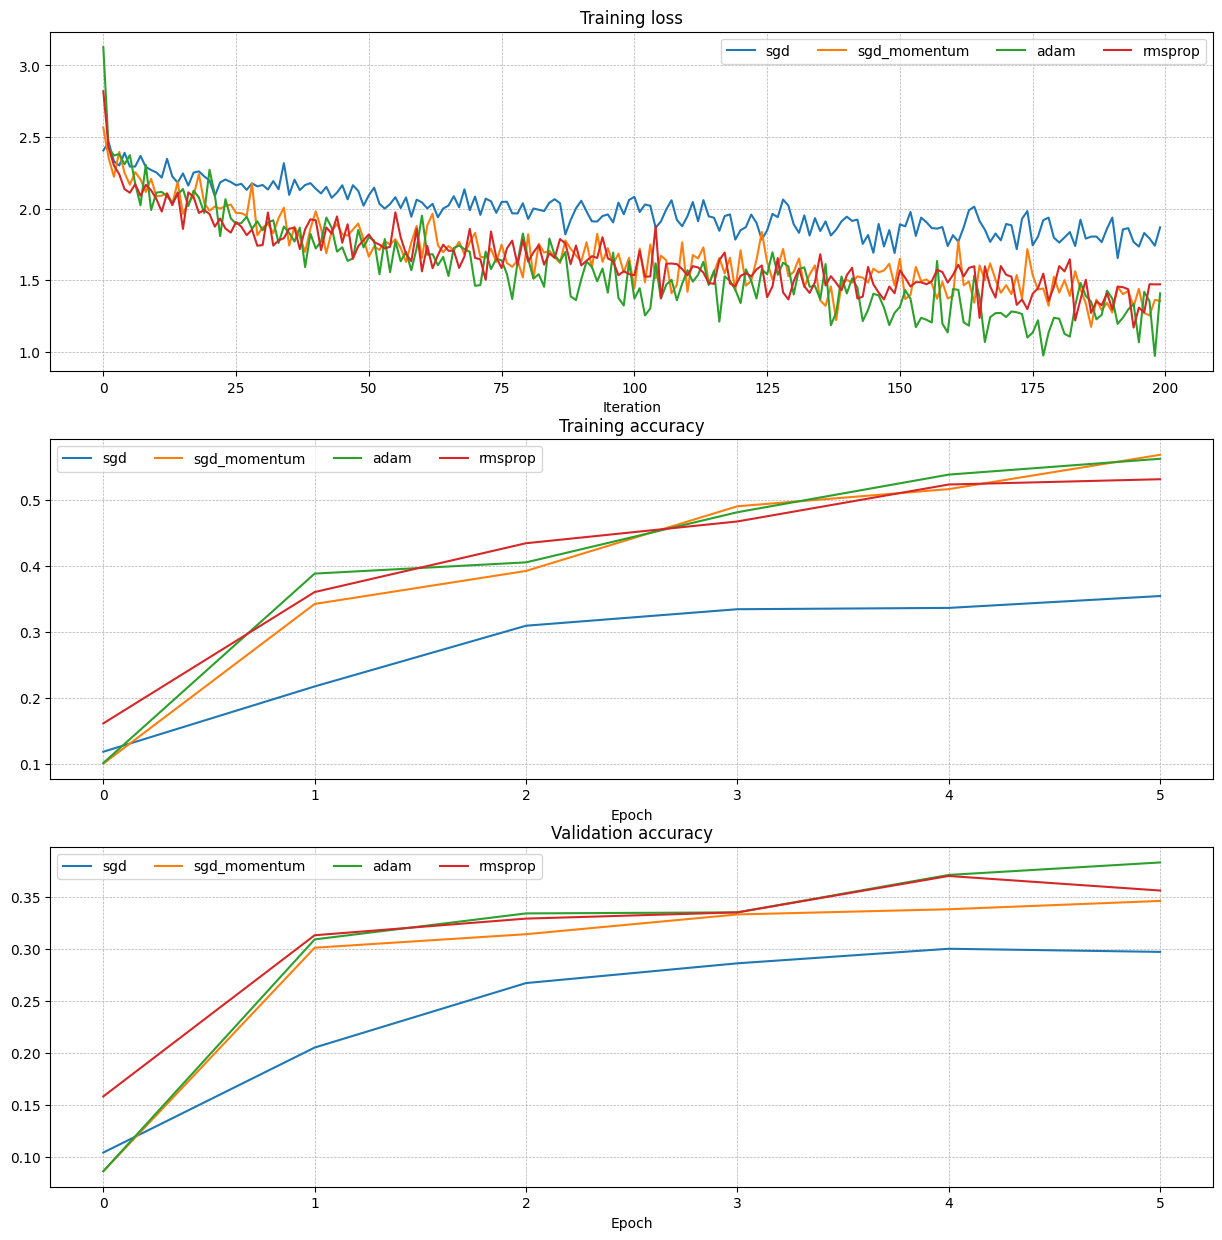

In [15]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2: / ## 内联问题 2：

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:
**AdaGrad和Adam一样，是一种每个参数的优化方法，使用以下更新规则：**

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?
**John注意到当他用AdaGrad训练网络时，更新变得非常小，网络学习缓慢。根据你对AdaGrad更新规则的了解，你认为为什么更新会变得非常小？Adam会有同样的问题吗？**

## Answer: / ## 答案：
[FILL THIS IN] / [填写此处]

# Train a Good Model! / 训练一个好的模型！

Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.
**在CIFAR-10上训练你能做到的最佳全连接模型，将最佳模型存储在`best_model`变量中。我们要求你使用全连接网络在验证集上达到至少50%的准确率。**

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.
**如果仔细调整，应该可以达到55%以上的准确率，但这部分我们不要求，也不会为此加分。在下一个作业中，我们会要求你在CIFAR-10上训练最佳的卷积网络，我们希望你把精力放在卷积网络上而不是全连接网络。**

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.
**注意：在下一个作业中，你将学习批量归一化和Dropout等技术，这些可以帮助你训练强大的模型。**

In [ ]:
best_model = None
best_val_acc = 0
################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
model = FullyConnectedNet([200, 100, 100])

lr = 1e-4

solver = Solver(
    model,
    data,
    update_rule='adam',
    batch_size=200,
    num_epochs=10,
    optim_config={'learning_rate': lr},
    print_every=200,
)

solver.train()

best_val_acc = solver.val_acc_history[-1]
print(f"val_acc = {best_val_acc}")

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

(Iteration 1 / 2450) loss: 2.304497
(Epoch 0 / 10) train acc: 0.141000; val_acc: 0.131000
(Iteration 201 / 2450) loss: 1.651500
(Epoch 1 / 10) train acc: 0.451000; val_acc: 0.444000
(Iteration 401 / 2450) loss: 1.641645
(Epoch 2 / 10) train acc: 0.485000; val_acc: 0.474000
(Iteration 601 / 2450) loss: 1.499324
(Epoch 3 / 10) train acc: 0.536000; val_acc: 0.486000
(Iteration 801 / 2450) loss: 1.340450
(Epoch 4 / 10) train acc: 0.523000; val_acc: 0.498000
(Iteration 1001 / 2450) loss: 1.341365
(Iteration 1201 / 2450) loss: 1.240185
(Epoch 5 / 10) train acc: 0.556000; val_acc: 0.521000
(Iteration 1401 / 2450) loss: 1.204288
(Epoch 6 / 10) train acc: 0.570000; val_acc: 0.530000
(Iteration 1601 / 2450) loss: 1.211681
(Epoch 7 / 10) train acc: 0.530000; val_acc: 0.528000
(Iteration 1801 / 2450) loss: 1.268840
(Epoch 8 / 10) train acc: 0.614000; val_acc: 0.524000
(Iteration 2001 / 2450) loss: 1.097131
(Iteration 2201 / 2450) loss: 1.169472
(Epoch 9 / 10) train acc: 0.608000; val_acc: 0.548000

# Test Your Model! / 测试你的模型！

Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.
**在验证集和测试集上运行你的最佳模型。你应该在验证集和测试集上达到至少50%的准确率。**

In [ ]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())